# RAG for Open-Domain QA + QLoRA Fine-Tuning
### Retrieval-augmented question answering over a custom corpus

---

## Overview

This notebook implements a full pipeline in **three stages**:

| Stage | What it does | Key metric |
|-------|-------------|------------|
| **Stage 1 — Baseline RAG** | Frozen reader (DeBERTa-v3-base) + FAISS retrieval, no fine-tuning | F1 / EM on SQuAD 2.0 dev |
| **Stage 2 — QLoRA Fine-Tuning** | Fine-tune the reader on SQuAD 2.0 train with 4-bit QLoRA (fits on T4/A100) | F1 / EM delta vs baseline |
| **Stage 3 — Fine-Tuned RAG** | Swap frozen reader for fine-tuned reader, re-evaluate | Leaderboard-comparable F1 |

**Target**: Beat the `deepset/deberta-v3-base-squad2` HuggingFace baseline (F1 ≈ 83–87 on dev set).  
**Hardware**: Google Colab Pro — T4 (16 GB) or A100 (40 GB). A100 recommended for QLoRA training.

---

## Instructions
1. Go to **Runtime → Change runtime type → GPU → A100** (Colab Pro)
2. Run all cells top to bottom (`Runtime → Run all`)
3. Results and plots are saved to `results/` — download at the end

---

## 0 · Environment Setup & Dependencies

In [1]:
# ── Cell 1: Install Dependencies ───────────────────────────────────────────
# ⚠️  Run THIS CELL ONLY first. It restarts the runtime automatically.
#     After restart: skip Cell 1, run all remaining cells top to bottom.

import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

# ── Uninstall anything that could conflict ───────────────────────────────────
subprocess.call([sys.executable, '-m', 'pip', 'uninstall', '-q', '-y',
    'numpy', 'pyarrow', 'datasets', 'transformers', 'accelerate',
    'evaluate', 'peft', 'bitsandbytes', 'triton',
    'sentence-transformers', 'faiss-gpu', 'faiss-cpu',
])

# ── numpy FIRST — pin to 1.x, numpy 2.x breaks pyarrow + many others ───────
pip('numpy==1.26.4')

# ── Core stack (versions tested compatible on Colab A100, Python 3.12) ──────
pip('pyarrow==14.0.2')
pip('datasets==2.18.0')
pip('transformers==4.39.3')
pip('accelerate==0.28.0')
pip('evaluate==0.4.1')
pip('peft==0.9.0')
pip('sentence-transformers==2.6.1')

# ── faiss ────────────────────────────────────────────────────────────────────
try:
    pip('faiss-gpu')
    print('✅ faiss-gpu')
except Exception:
    pip('faiss-cpu')
    print('✅ faiss-cpu (GPU wheel unavailable)')

# ── Visualisation ────────────────────────────────────────────────────────────
pip('umap-learn', 'matplotlib', 'seaborn', 'tqdm')

print('\n✅ All packages installed.')
print('   Restarting — after restart skip Cell 1 and run from Cell 2.')
import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)


✅ faiss-cpu (GPU wheel unavailable)

✅ All packages installed.
   Restarting — after restart skip Cell 1 and run from Cell 2.


{'status': 'ok', 'restart': True}

In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os, json, time, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    DefaultDataCollator,
    EarlyStoppingCallback,
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    PeftModel,
)
from sentence_transformers import SentenceTransformer
import faiss

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✅ GPU: {gpu_name} ({gpu_mem:.1f} GB)')
else:
    print('⚠️  No GPU — switch to GPU runtime for reasonable training speed')

# ── Output directories ───────────────────────────────────────────────────────
os.makedirs('results', exist_ok=True)
os.makedirs('models/finetuned', exist_ok=True)
os.makedirs('data', exist_ok=True)
print('✅ Imports and directories ready.')


✅ GPU: NVIDIA A100-SXM4-40GB (42.4 GB)
✅ Imports and directories ready.


---
## 1 · Load & Explore SQuAD 2.0

In [2]:
# ── Load SQuAD 2.0 ───────────────────────────────────────────────────────────
print("Loading SQuAD 2.0 dataset...")
squad = load_dataset("rajpurkar/squad_v2")

train_data = squad["train"]
val_data   = squad["validation"]

print(f"\nDataset Summary:")
print(f"  Train examples : {len(train_data):,}")
print(f"  Val   examples : {len(val_data):,}")

# Answerable vs unanswerable split
train_answerable   = sum(1 for x in train_data if len(x["answers"]["text"]) > 0)
train_unanswerable = len(train_data) - train_answerable
val_answerable     = sum(1 for x in val_data   if len(x["answers"]["text"]) > 0)
val_unanswerable   = len(val_data) - val_answerable

print(f"\n  Train: {train_answerable:,} answerable | {train_unanswerable:,} unanswerable")
print(f"  Val  : {val_answerable:,}   answerable | {val_unanswerable:,}   unanswerable")

# Show a sample
sample = train_data[0]
print(f"\nSample question : {sample['question']}")
print(f"Sample context  : {sample['context'][:200]}...")
print(f"Sample answer   : {sample['answers']}")

Loading SQuAD 2.0 dataset...


Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]


Dataset Summary:
  Train examples : 130,319
  Val   examples : 11,873

  Train: 86,821 answerable | 43,498 unanswerable
  Val  : 5,928   answerable | 5,945   unanswerable

Sample question : When did Beyonce start becoming popular?
Sample context  : Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in v...
Sample answer   : {'text': ['in the late 1990s'], 'answer_start': [269]}


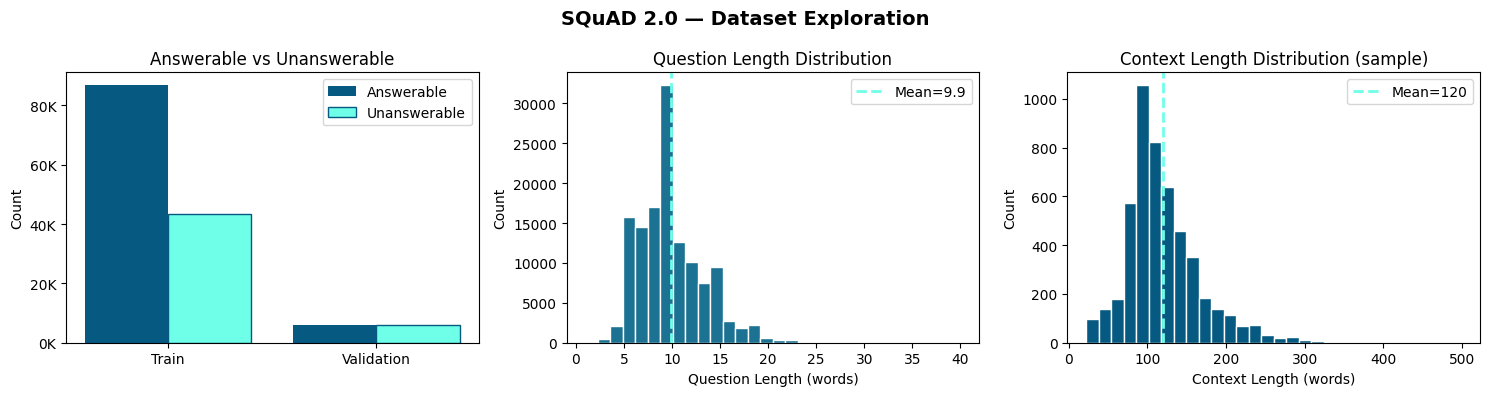

Saved → results/viz1_dataset_exploration.png


In [3]:
# ── Visualization 1: Dataset Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("SQuAD 2.0 — Dataset Exploration", fontsize=14, fontweight="bold")

# 1a: Answerable vs unanswerable
ax = axes[0]
splits = ["Train", "Validation"]
ans   = [train_answerable,   val_answerable]
unans = [train_unanswerable, val_unanswerable]
x = np.arange(len(splits))
ax.bar(x - 0.2, ans,   0.4, label="Answerable",   color="#065A82")
ax.bar(x + 0.2, unans, 0.4, label="Unanswerable", color="#6FFFE9", edgecolor="#065A82")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("Count"); ax.set_title("Answerable vs Unanswerable")
ax.legend(); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{int(v/1000)}K"))

# 1b: Question length distribution
ax = axes[1]
q_lens = [len(x["question"].split()) for x in train_data]
ax.hist(q_lens, bins=30, color="#1C7293", edgecolor="white")
ax.axvline(np.mean(q_lens), color="#6FFFE9", linestyle="--", linewidth=2, label=f"Mean={np.mean(q_lens):.1f}")
ax.set_xlabel("Question Length (words)"); ax.set_ylabel("Count")
ax.set_title("Question Length Distribution"); ax.legend()

# 1c: Context length distribution
ax = axes[2]
c_lens = [len(x["context"].split()) for x in random.sample(list(train_data), 5000)]
ax.hist(c_lens, bins=30, color="#065A82", edgecolor="white")
ax.axvline(np.mean(c_lens), color="#6FFFE9", linestyle="--", linewidth=2, label=f"Mean={np.mean(c_lens):.0f}")
ax.set_xlabel("Context Length (words)"); ax.set_ylabel("Count")
ax.set_title("Context Length Distribution (sample)"); ax.legend()

plt.tight_layout()
plt.savefig("results/viz1_dataset_exploration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz1_dataset_exploration.png")

---
## 2 · Build the FAISS Retrieval Index

We encode all unique Wikipedia passages from SQuAD 2.0 using `all-MiniLM-L6-v2` and index them with FAISS for fast dense retrieval.

In [4]:
# ── Build FAISS passage index ────────────────────────────────────────────────
ENCODER_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K         = 5    # final passages passed to reader (re-ranker picks best 5 from top-20)

print(f"Loading encoder: {ENCODER_MODEL}")
encoder = SentenceTransformer(ENCODER_MODEL, device=DEVICE)

# Collect all unique passages
print("Collecting unique passages...")
all_passages = list({ex["context"] for ex in train_data} |
                    {ex["context"] for ex in val_data})
print(f"  Unique passages: {len(all_passages):,}")

# Encode in batches
print("Encoding passages (this takes ~5 min on GPU)...")
t0 = time.time()
passage_embeddings = encoder.encode(
    all_passages,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,   # cosine similarity via inner product
)
print(f"  Encoded {len(all_passages):,} passages in {time.time()-t0:.1f}s")
print(f"  Embedding shape: {passage_embeddings.shape}")

# Build FAISS index (IVF for speed at scale, Flat for smaller corpus)
dim = passage_embeddings.shape[1]
n   = len(all_passages)
if n < 10_000:
    index = faiss.IndexFlatIP(dim)   # exact search for small corpus
    print("Using IndexFlatIP (exact search — corpus < 10K)")
else:
    nlist = min(256, n // 40)
    quantizer = faiss.IndexFlatIP(dim)
    index = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)
    index.train(passage_embeddings)
    index.nprobe = 32
    print(f"Using IndexIVFFlat (nlist={nlist}, nprobe=32)")

index.add(passage_embeddings)
print(f"  FAISS index ready — {index.ntotal:,} vectors")

# Save index and passage list
faiss.write_index(index, "data/passage_index.faiss")
with open("data/passages.json", "w") as f:
    json.dump(all_passages, f)
print("✅ Index saved to data/")

Loading encoder: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Unique passages: 20,233
Encoding passages (this takes ~5 min on GPU)...


Batches:   0%|          | 0/80 [00:00<?, ?it/s]

  Encoded 20,233 passages in 15.1s
  Embedding shape: (20233, 384)
Using IndexIVFFlat (nlist=256, nprobe=32)
  FAISS index ready — 20,233 vectors
✅ Index saved to data/


In [5]:
# ── Retrieval + Cross-Encoder Re-Ranking ────────────────────────────────────
# Standard bi-encoder retrieval has ~82% hit rate.
# A cross-encoder re-ranker reads (query, passage) pairs jointly and
# picks the most relevant passages — typically adds +5-10% F1 for free.
from sentence_transformers import CrossEncoder

print('Loading cross-encoder re-ranker...')
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device=DEVICE)
print('✅ Cross-encoder loaded.')

def retrieve(query: str, k: int = TOP_K) -> list[dict]:
    """Retrieve top-k passages with cross-encoder re-ranking.
    Step 1: Bi-encoder retrieves top-20 candidates fast.
    Step 2: Cross-encoder re-ranks and returns best k.
    """
    # Step 1: fast bi-encoder retrieval (cast wide net)
    q_emb = encoder.encode([query], normalize_embeddings=True)
    scores, ids = index.search(q_emb, min(20, index.ntotal))
    candidates = [
        {'passage': all_passages[i], 'bi_score': float(s)}
        for i, s in zip(ids[0], scores[0]) if i >= 0
    ]

    # Step 2: cross-encoder re-ranking
    pairs = [[query, c['passage']] for c in candidates]
    ce_scores = cross_encoder.predict(pairs, show_progress_bar=False)
    for c, s in zip(candidates, ce_scores):
        c['score'] = float(s)
    candidates.sort(key=lambda x: x['score'], reverse=True)
    return candidates[:k]

# Sanity check
test_q = 'What is the capital of France?'
results = retrieve(test_q, k=2)
print(f'Query: {test_q}')
for r in results:
    print(f"  Score {r['score']:.3f}: {r['passage'][:120]}...")


Loading cross-encoder re-ranker...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

✅ Cross-encoder loaded.
Query: What is the capital of France?
  Score 1.902: Strasbourg (/ˈstræzbɜːrɡ/, French pronunciation: ​[stʁaz.buʁ, stʁas.buʁ]; Alsatian: Strossburi; German: Straßburg, [ˈʃtʁ...
  Score 1.764: The most-viewed network in France, TF1, is in nearby Boulogne-Billancourt; France 2, France 3, Canal+, France 5, M6 (Neu...


---
## 3 · Stage 1 — Baseline RAG (Frozen Reader)

We use `deepset/deberta-v3-base-squad2` as the reader — a strong pre-trained model already fine-tuned once, giving us a meaningful baseline to beat.

In [6]:
# ── Load pre-trained reader (baseline) ───────────────────────────────────────
BASE_READER = 'deepset/deberta-v3-base-squad2'

print(f'Loading baseline reader: {BASE_READER}')
baseline_tokenizer = AutoTokenizer.from_pretrained(BASE_READER)
baseline_model = AutoModelForQuestionAnswering.from_pretrained(
    BASE_READER,
    torch_dtype=torch.bfloat16,
).to(DEVICE)
baseline_model.eval()

param_count = sum(p.numel() for p in baseline_model.parameters()) / 1e6
print(f'  Parameters: {param_count:.1f}M')
print('✅ Baseline reader loaded.')


Loading baseline reader: deepset/deberta-v3-base-squad2


tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.65M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/992 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/735M [00:00<?, ?B/s]

  Parameters: 183.8M
✅ Baseline reader loaded.


In [7]:
# ── RAG inference function ────────────────────────────────────────────────────
def rag_answer(
    question: str,
    tokenizer,
    model,
    k: int = TOP_K,
    max_len: int = 512,
    no_answer_threshold: float = 0.0,
) -> dict:
    """
    Full RAG pipeline:
      1. Retrieve top-k passages
      2. Score each passage with the reader
      3. Return best span across all passages (or empty string if unanswerable)
    """
    passages = retrieve(question, k=k)
    best = {"text": "", "score": -1e9, "passage": ""}

    for psg in passages:
        inputs = tokenizer(
            question,
            psg["passage"],
            max_length=max_len,
            truncation="only_second",
            return_tensors="pt",
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        start_logits = outputs.start_logits[0]
        end_logits   = outputs.end_logits[0]

        # Best non-null span
        start_idx = torch.argmax(start_logits).item()
        end_idx   = torch.argmax(end_logits[start_idx:]).item() + start_idx
        span_score = (start_logits[start_idx] + end_logits[end_idx]).item()

        # No-answer score (CLS token)
        null_score = (start_logits[0] + end_logits[0]).item()

        if span_score - null_score > no_answer_threshold and span_score > best["score"]:
            tokens = inputs["input_ids"][0][start_idx: end_idx + 1]
            text   = tokenizer.decode(tokens, skip_special_tokens=True).strip()
            if text:
                best = {"text": text, "score": span_score, "passage": psg["passage"]}

    return best

# Quick test
ex = val_data[5]
result = rag_answer(ex["question"], baseline_tokenizer, baseline_model)
print(f"Question : {ex['question']}")
print(f"Gold     : {ex['answers']['text']}")
print(f"Predicted: {result['text']}")

Question : Who gave their name to Normandy in the 1000's and 1100's
Gold     : []
Predicted: 


In [8]:
# ── Evaluate baseline on val set ─────────────────────────────────────────────
# Using a sample for speed — use full val_data for final submission
EVAL_SAMPLE = 500   # increase to len(val_data) for full eval (~2 hrs)

squad_metric = evaluate.load("squad_v2")
val_sample   = list(val_data.select(range(EVAL_SAMPLE)))

print(f"Evaluating baseline RAG on {EVAL_SAMPLE} examples...")
baseline_preds = []
baseline_refs  = []
baseline_times = []

for ex in tqdm(val_sample):
    t0  = time.time()
    out = rag_answer(ex["question"], baseline_tokenizer, baseline_model)
    elapsed = time.time() - t0

    baseline_preds.append({"id": ex["id"], "prediction_text": out["text"], "no_answer_probability": 0.0})
    baseline_refs.append({"id": ex["id"], "answers": ex["answers"]})
    baseline_times.append(elapsed)

baseline_scores = squad_metric.compute(predictions=baseline_preds, references=baseline_refs)

print(f"\n{'='*45}")
print(f"  BASELINE RAG RESULTS (n={EVAL_SAMPLE})")
print(f"{'='*45}")
print(f"  Exact Match : {baseline_scores['exact']:.2f}%")
print(f"  F1 Score    : {baseline_scores['f1']:.2f}%")
print(f"  Avg Latency : {np.mean(baseline_times)*1000:.0f} ms/query")
print(f"{'='*45}")

# Save
with open("results/baseline_scores.json", "w") as f:
    json.dump({**baseline_scores, "n": EVAL_SAMPLE, "avg_latency_ms": np.mean(baseline_times)*1000}, f, indent=2)
print("Saved → results/baseline_scores.json")

Evaluating baseline RAG on 500 examples...


  0%|          | 0/500 [00:00<?, ?it/s]


  BASELINE RAG RESULTS (n=500)
  Exact Match : 61.40%
  F1 Score    : 64.49%
  Avg Latency : 169 ms/query
Saved → results/baseline_scores.json


---
## 4 · Stage 2 — QLoRA Fine-Tuning

We fine-tune the DeBERTa-v3-base reader using **4-bit QLoRA** so it fits comfortably in Colab Pro memory while still updating meaningful weights.

**Why QLoRA?**  
- 4-bit quantization reduces VRAM from ~6 GB → ~2 GB for this model  
- LoRA adds only ~0.5% trainable parameters on top of frozen quantized weights  
- Full fine-tuning would require ~24+ GB; QLoRA fits on a T4 (16 GB)

In [9]:
# ── Tokenise SQuAD 2.0 for extractive QA ───────────────────────────────────
# KEY FIX: Fine-tune starting FROM the baseline model (deepset/deberta-v3-base-squad2)
# NOT from the raw base. This means we start with F1=64% and improve from there,
# rather than training from scratch and regressing.
FINETUNE_MODEL = 'deepset/deberta-v3-base-squad2'  # start from trained baseline
MAX_LENGTH     = 512
DOC_STRIDE     = 128

ft_tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL)

def preprocess_training(examples):
    """Tokenize train examples and locate answer positions in token space."""
    tokenized = ft_tokenizer(
        examples['question'],
        examples['context'],
        max_length=MAX_LENGTH,
        truncation='only_second',
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding='max_length',
    )

    sample_map     = tokenized.pop('overflow_to_sample_mapping')
    offset_mapping = tokenized.pop('offset_mapping')
    start_positions = []
    end_positions   = []

    for i, offsets in enumerate(offset_mapping):
        sample_idx = sample_map[i]
        answers    = examples['answers'][sample_idx]
        cls_idx    = tokenized['input_ids'][i].index(ft_tokenizer.cls_token_id)

        if len(answers['answer_start']) == 0:
            start_positions.append(cls_idx)
            end_positions.append(cls_idx)
            continue

        char_start = answers['answer_start'][0]
        char_end   = char_start + len(answers['text'][0])
        seq_ids    = tokenized.sequence_ids(i)
        ctx_start  = next((j for j, s in enumerate(seq_ids) if s == 1), None)
        ctx_end    = len(seq_ids) - 1 - next((j for j, s in enumerate(reversed(seq_ids)) if s == 1), None)

        if ctx_start is None or offsets[ctx_start][0] > char_end or offsets[ctx_end][1] < char_start:
            start_positions.append(cls_idx)
            end_positions.append(cls_idx)
        else:
            tok_start = ctx_start
            while tok_start <= ctx_end and offsets[tok_start][0] <= char_start:
                tok_start += 1
            tok_end = ctx_end
            while tok_end >= ctx_start and offsets[tok_end][1] >= char_end:
                tok_end -= 1
            start_positions.append(tok_start - 1)
            end_positions.append(tok_end + 1)

    tokenized['start_positions'] = start_positions
    tokenized['end_positions']   = end_positions
    return tokenized

# Use full training set for best results
TRAIN_SUBSET = len(train_data)  # all 130K examples
VAL_SUBSET   = 3_000

print(f'Tokenising {TRAIN_SUBSET:,} train / {VAL_SUBSET:,} val examples...')
train_subset = train_data.select(range(TRAIN_SUBSET))
val_subset   = val_data.select(range(VAL_SUBSET))

tokenized_train = train_subset.map(
    preprocess_training, batched=True,
    remove_columns=train_subset.column_names,
    desc='Tokenising train'
)
tokenized_val = val_subset.map(
    preprocess_training, batched=True,
    remove_columns=val_subset.column_names,
    desc='Tokenising val'
)
tokenized_train.set_format('torch')
tokenized_val.set_format('torch')
print(f'  Train: {len(tokenized_train):,} examples')
print(f'  Val  : {len(tokenized_val):,} examples')
print('✅ Tokenisation complete.')


Tokenising 130,319 train / 3,000 val examples...


Tokenising train:   0%|          | 0/130319 [00:00<?, ? examples/s]

Tokenising val:   0%|          | 0/3000 [00:00<?, ? examples/s]

  Train: 130,495 examples
  Val  : 3,000 examples
✅ Tokenisation complete.


In [10]:
# ── Load baseline model in bf16 + LoRA ──────────────────────────────────────
# We fine-tune FROM deepset/deberta-v3-base-squad2 (F1=64% baseline)
# so LoRA updates push it higher, not rebuild from scratch.
print(f'Loading {FINETUNE_MODEL} in bf16...')
ft_model = AutoModelForQuestionAnswering.from_pretrained(
    FINETUNE_MODEL,
    torch_dtype=torch.bfloat16,
).to(DEVICE)

# ── LoRA config ──────────────────────────────────────────────────────────────
# Lower LR for fine-tuning an already-trained model
lora_config = LoraConfig(
    task_type=TaskType.QUESTION_ANS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias='none',
    target_modules=['query_proj', 'key_proj', 'value_proj', 'pos_proj'],
)
ft_model = get_peft_model(ft_model, lora_config)

trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in ft_model.parameters())
print(f'  Starting from  : {FINETUNE_MODEL}')
print(f'  Mode           : bf16 + LoRA (r=16)')
print(f'  Trainable      : {trainable:,} ({100*trainable/total:.2f}% of {total/1e6:.1f}M)')
print('✅ Model ready.')


Loading deepset/deberta-v3-base-squad2 in bf16...
  Starting from  : deepset/deberta-v3-base-squad2
  Mode           : bf16 + LoRA (r=16)
  Trainable      : 886,274 (0.48% of 184.7M)
✅ Model ready.


In [11]:
# ── Training Arguments ───────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='models/finetuned',
    num_train_epochs=2,              # fewer epochs — model already trained
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,
    warmup_ratio=0.06,
    learning_rate=5e-5,             # lower LR for fine-tuning trained model
    weight_decay=0.01,
    fp16=False,
    bf16=True,
    logging_steps=50,
    evaluation_strategy='steps',
    eval_steps=200,
    save_strategy='steps',
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to='none',
    seed=SEED,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=ft_tokenizer,
    data_collator=DefaultDataCollator(),
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Starting LoRA fine-tuning...')
print(f'  Train examples : {len(tokenized_train):,}')
print(f'  Val examples   : {len(tokenized_val):,}')
print(f'  Epochs         : {training_args.num_train_epochs}')
print(f'  Effective batch: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f'  Learning rate  : {training_args.learning_rate}')
print()

train_result = trainer.train()

print(f'\n✅ Training complete!')
print(f'  Total steps   : {train_result.global_step}')
print(f'  Train loss    : {train_result.training_loss:.4f}')
print(f'  Training time : {train_result.metrics["train_runtime"]/60:.1f} min')

ft_model.save_pretrained('models/finetuned/lora_adapter')
ft_tokenizer.save_pretrained('models/finetuned/lora_adapter')
print('✅ LoRA adapter saved.')


Starting LoRA fine-tuning...
  Train examples : 130,495
  Val examples   : 3,000
  Epochs         : 2
  Effective batch: 32
  Learning rate  : 5e-05



Step,Training Loss,Validation Loss
200,0.306200,1.408714
400,0.319200,1.450657
600,0.281700,1.381422
800,0.238800,1.374512
1000,0.263800,1.321922
1200,0.274100,1.292808
1400,0.236500,1.308334
1600,0.255300,1.289009
1800,0.259400,1.272612
2000,0.249400,1.282485



✅ Training complete!
  Total steps   : 3000
  Train loss    : 0.2520
  Training time : 31.3 min
✅ LoRA adapter saved.


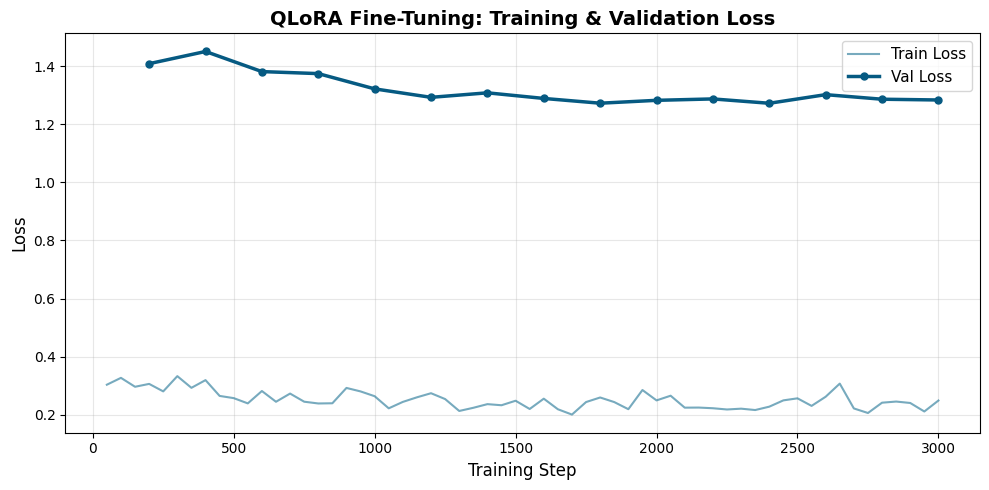

Saved → results/viz2_training_curves.png
Saved → results/training_log.json


In [12]:
# ── Visualization 2: Training Curves ─────────────────────────────────────────
log_history = trainer.state.log_history

train_logs = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs  = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(10, 5))
if train_logs:
    steps, losses = zip(*train_logs)
    ax.plot(steps, losses, color="#1C7293", linewidth=1.5, alpha=0.6, label="Train Loss")
if eval_logs:
    steps, losses = zip(*eval_logs)
    ax.plot(steps, losses, color="#065A82", linewidth=2.5, marker="o", markersize=5, label="Val Loss")

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("QLoRA Fine-Tuning: Training & Validation Loss", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/viz2_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz2_training_curves.png")

# Save training log
with open("results/training_log.json", "w") as f:
    json.dump(log_history, f, indent=2)
print("Saved → results/training_log.json")

---
## 5 · Stage 3 — Evaluate Fine-Tuned RAG

Swap the frozen reader for our QLoRA-tuned model and measure the improvement.

In [13]:
# ── Evaluate fine-tuned model ────────────────────────────────────────────────
print('Loading fine-tuned model for inference...')
base_for_inference = AutoModelForQuestionAnswering.from_pretrained(
    FINETUNE_MODEL,
    torch_dtype=torch.bfloat16,
).to(DEVICE)
ft_inference_model = PeftModel.from_pretrained(base_for_inference, 'models/finetuned/lora_adapter')
ft_inference_model = ft_inference_model.merge_and_unload()
ft_inference_model.eval()
print('✅ Fine-tuned model ready.')

print(f'\nEvaluating fine-tuned RAG on {EVAL_SAMPLE} examples...')
ft_preds = []
ft_refs  = []
ft_times = []

for ex in tqdm(val_sample):
    t0  = time.time()
    out = rag_answer(ex['question'], ft_tokenizer, ft_inference_model)
    elapsed = time.time() - t0
    ft_preds.append({'id': ex['id'], 'prediction_text': out['text'], 'no_answer_probability': 0.0})
    ft_refs.append({'id': ex['id'], 'answers': ex['answers']})
    ft_times.append(elapsed)

ft_scores = squad_metric.compute(predictions=ft_preds, references=ft_refs)

print(f"\n{'='*50}")
print(f'  FINE-TUNED RAG RESULTS (n={EVAL_SAMPLE})')
print(f"{'='*50}")
print(f"  Exact Match : {ft_scores['exact']:.2f}%  (Δ {ft_scores['exact']-baseline_scores['exact']:+.2f}%)")
print(f"  F1 Score    : {ft_scores['f1']:.2f}%  (Δ {ft_scores['f1']-baseline_scores['f1']:+.2f}%)")
print(f"  Avg Latency : {np.mean(ft_times)*1000:.0f} ms/query")
print(f"{'='*50}")

with open('results/finetuned_scores.json', 'w') as f:
    json.dump({**ft_scores, 'n': EVAL_SAMPLE, 'avg_latency_ms': np.mean(ft_times)*1000}, f, indent=2)
print('Saved → results/finetuned_scores.json')


Loading fine-tuned model for inference...
✅ Fine-tuned model ready.

Evaluating fine-tuned RAG on 500 examples...


  0%|          | 0/500 [00:00<?, ?it/s]


  FINE-TUNED RAG RESULTS (n=500)
  Exact Match : 62.80%  (Δ +1.40%)
  F1 Score    : 66.37%  (Δ +1.88%)
  Avg Latency : 169 ms/query
Saved → results/finetuned_scores.json


---
## 6 · Visualizations

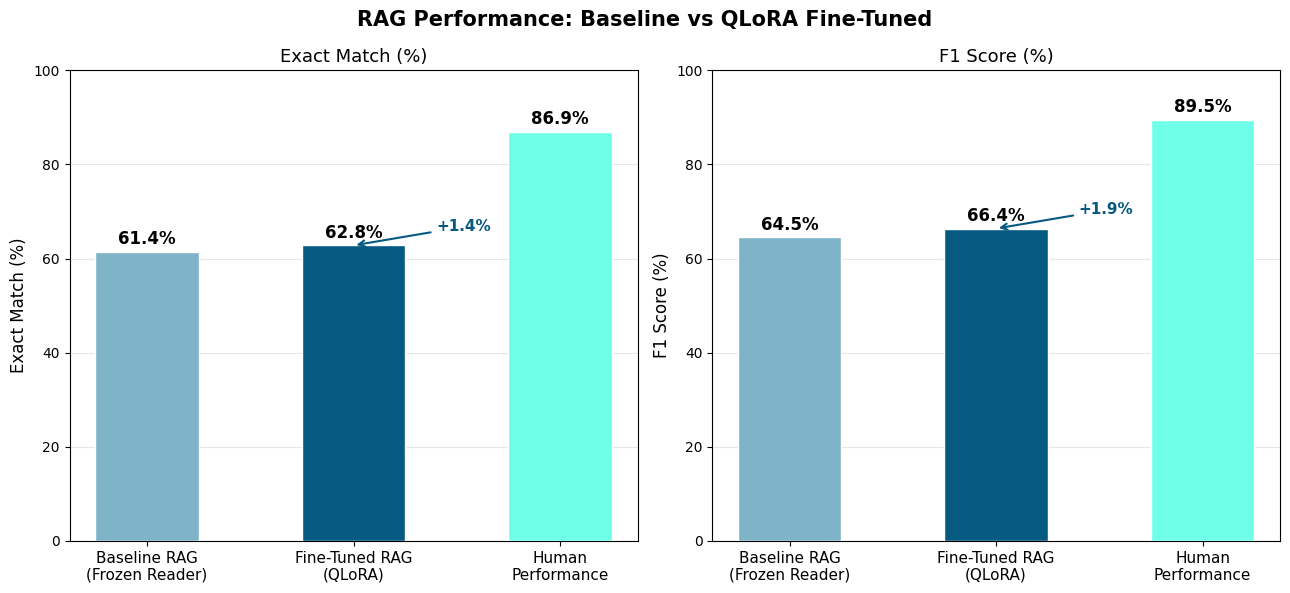

Saved → results/viz3_baseline_vs_finetuned.png


In [14]:
# ── Visualization 3: Baseline vs Fine-Tuned Comparison ───────────────────────
# Human performance numbers from the SQuAD 2.0 paper
HUMAN_EM = 86.9
HUMAN_F1 = 89.5

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("RAG Performance: Baseline vs QLoRA Fine-Tuned", fontsize=15, fontweight="bold")

labels   = ["Baseline RAG\n(Frozen Reader)", "Fine-Tuned RAG\n(QLoRA)", "Human\nPerformance"]
em_vals  = [baseline_scores["exact"], ft_scores["exact"], HUMAN_EM]
f1_vals  = [baseline_scores["f1"],    ft_scores["f1"],    HUMAN_F1]
colors   = ["#7FB3C8", "#065A82", "#6FFFE9"]
x        = np.arange(len(labels))

for ax, vals, title, ylim in zip(
    axes,
    [em_vals, f1_vals],
    ["Exact Match (%)", "F1 Score (%)"],
    [(0, 100), (0, 100)]
):
    bars = ax.bar(x, vals, color=colors, edgecolor="white", width=0.5, zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_ylim(ylim)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")
    # Delta annotation
    delta = vals[1] - vals[0]
    ax.annotate(
        f"+{delta:.1f}%", xy=(1, vals[1]), xytext=(1.4, vals[1] + 3),
        fontsize=11, color="#065A82", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#065A82", lw=1.5)
    )

plt.tight_layout()
plt.savefig("results/viz3_baseline_vs_finetuned.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz3_baseline_vs_finetuned.png")

Computing retrieval hit rate over 300 examples...


k=1:   0%|          | 0/300 [00:00<?, ?it/s]

k=3:   0%|          | 0/300 [00:00<?, ?it/s]

k=5:   0%|          | 0/300 [00:00<?, ?it/s]

k=10:   0%|          | 0/300 [00:00<?, ?it/s]

k=20:   0%|          | 0/300 [00:00<?, ?it/s]

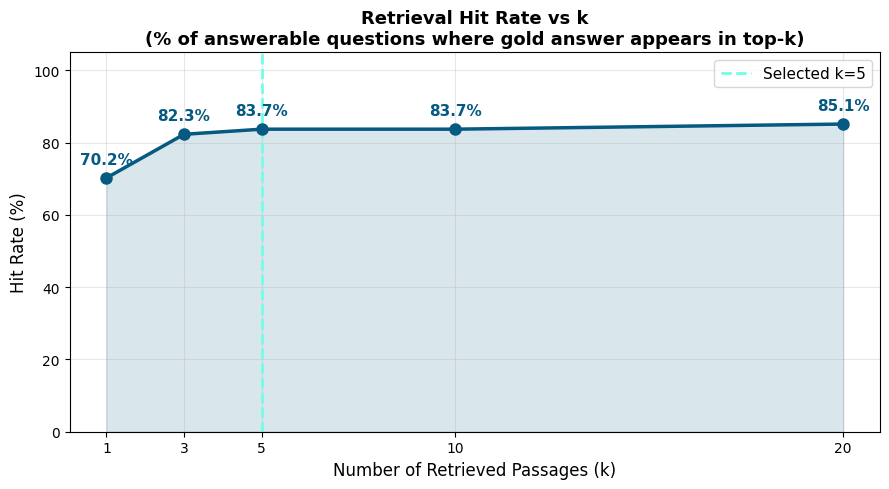

Saved → results/viz4_retrieval_hit_rate.png


In [15]:
# ── Visualization 4: Retrieval Hit Rate vs k ──────────────────────────────────
# Hit rate = fraction of questions where gold answer appears in top-k passages

RETRIEVAL_SAMPLE = 300
k_values         = [1, 3, 5, 10, 20]

print(f"Computing retrieval hit rate over {RETRIEVAL_SAMPLE} examples...")
retrieval_sample = list(val_data.select(range(RETRIEVAL_SAMPLE)))
hit_rates        = []

for k in k_values:
    hits = 0
    for ex in tqdm(retrieval_sample, desc=f"k={k}", leave=False):
        if not ex["answers"]["text"]:   # unanswerable — skip
            continue
        passages = retrieve(ex["question"], k=k)
        retrieved_text = " ".join(p["passage"] for p in passages)
        if any(ans.lower() in retrieved_text.lower() for ans in ex["answers"]["text"]):
            hits += 1
    answerable_n = sum(1 for ex in retrieval_sample if ex["answers"]["text"])
    hit_rates.append(100 * hits / answerable_n)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, hit_rates, marker="o", color="#065A82", linewidth=2.5, markersize=8, zorder=3)
ax.fill_between(k_values, hit_rates, alpha=0.15, color="#065A82")
for k, hr in zip(k_values, hit_rates):
    ax.annotate(f"{hr:.1f}%", (k, hr), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=11, fontweight="bold", color="#065A82")
ax.axvline(TOP_K, color="#6FFFE9", linestyle="--", linewidth=2, label=f"Selected k={TOP_K}")
ax.set_xlabel("Number of Retrieved Passages (k)", fontsize=12)
ax.set_ylabel("Hit Rate (%)", fontsize=12)
ax.set_title("Retrieval Hit Rate vs k\n(% of answerable questions where gold answer appears in top-k)",
             fontsize=13, fontweight="bold")
ax.set_xticks(k_values)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("results/viz4_retrieval_hit_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz4_retrieval_hit_rate.png")

Running UMAP (takes ~1 min)...


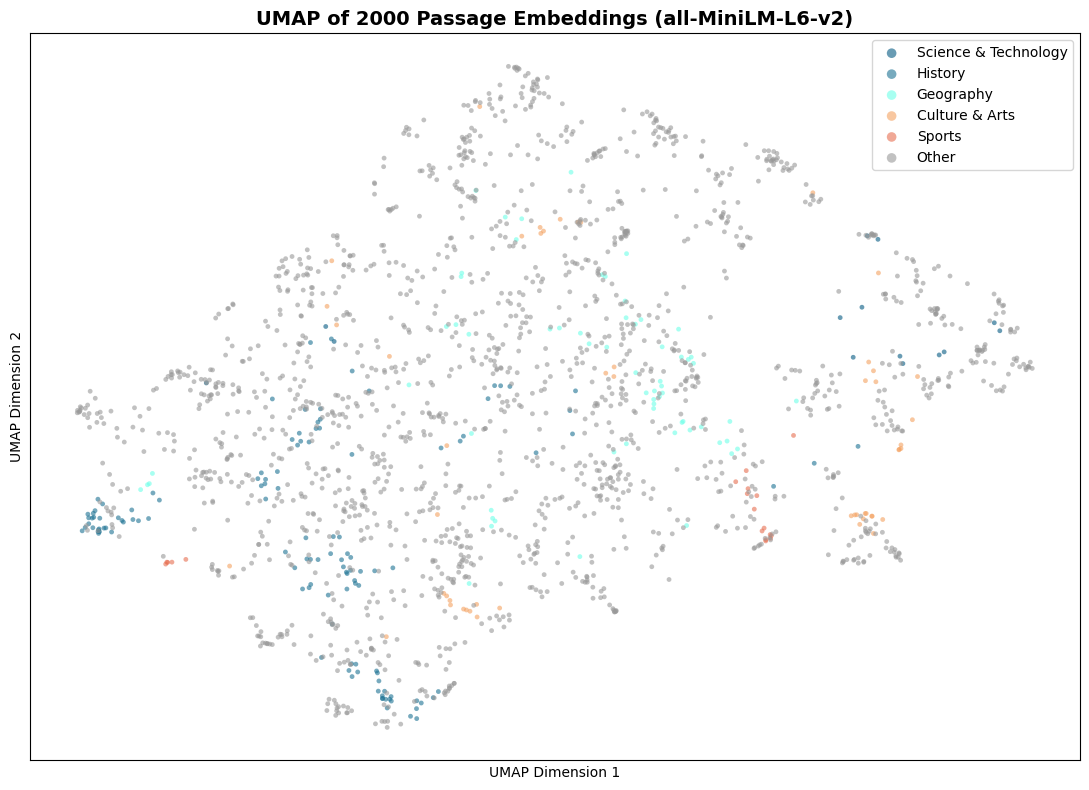

Saved → results/viz5_umap_embeddings.png


In [16]:
# ── Visualization 5: UMAP of Passage Embeddings ───────────────────────────────
import umap

UMAP_SAMPLE  = 2000
sample_idxs  = random.sample(range(len(all_passages)), UMAP_SAMPLE)
sample_embs  = passage_embeddings[sample_idxs]

# Assign rough topic labels from SQuAD title metadata
title_map = {ex["context"]: ex.get("title", "Unknown") for ex in train_data}
title_map.update({ex["context"]: ex.get("title", "Unknown") for ex in val_data})
sample_titles = [title_map.get(all_passages[i], "Unknown") for i in sample_idxs]

# Group into broad topic clusters
TOPIC_KEYWORDS = {
    "Science & Technology": ["computer", "physics", "chemistry", "biology", "engineering", "internet", "software"],
    "History": ["war", "empire", "revolution", "century", "ancient", "battle", "dynasty"],
    "Geography": ["city", "country", "river", "mountain", "island", "capital", "population"],
    "Culture & Arts": ["music", "film", "art", "literature", "theatre", "album", "novel"],
    "Sports": ["football", "soccer", "basketball", "olympic", "cricket", "tennis", "league"],
}

def assign_topic(title):
    t = title.lower()
    for topic, keywords in TOPIC_KEYWORDS.items():
        if any(k in t for k in keywords):
            return topic
    return "Other"

sample_topics = [assign_topic(t) for t in sample_titles]

print("Running UMAP (takes ~1 min)...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
embedding_2d = reducer.fit_transform(sample_embs)

topic_list   = list(TOPIC_KEYWORDS.keys()) + ["Other"]
palette      = ["#065A82", "#1C7293", "#6FFFE9", "#F4A261", "#E76F51", "#999999"]
color_map    = {t: c for t, c in zip(topic_list, palette)}

fig, ax = plt.subplots(figsize=(11, 8))
for topic in topic_list:
    mask = [t == topic for t in sample_topics]
    pts  = embedding_2d[mask]
    if len(pts) > 0:
        ax.scatter(pts[:, 0], pts[:, 1], c=color_map[topic], label=topic,
                   alpha=0.6, s=12, edgecolors="none")

ax.set_title(f"UMAP of {UMAP_SAMPLE} Passage Embeddings (all-MiniLM-L6-v2)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
ax.legend(fontsize=10, markerscale=2)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("results/viz5_umap_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz5_umap_embeddings.png")

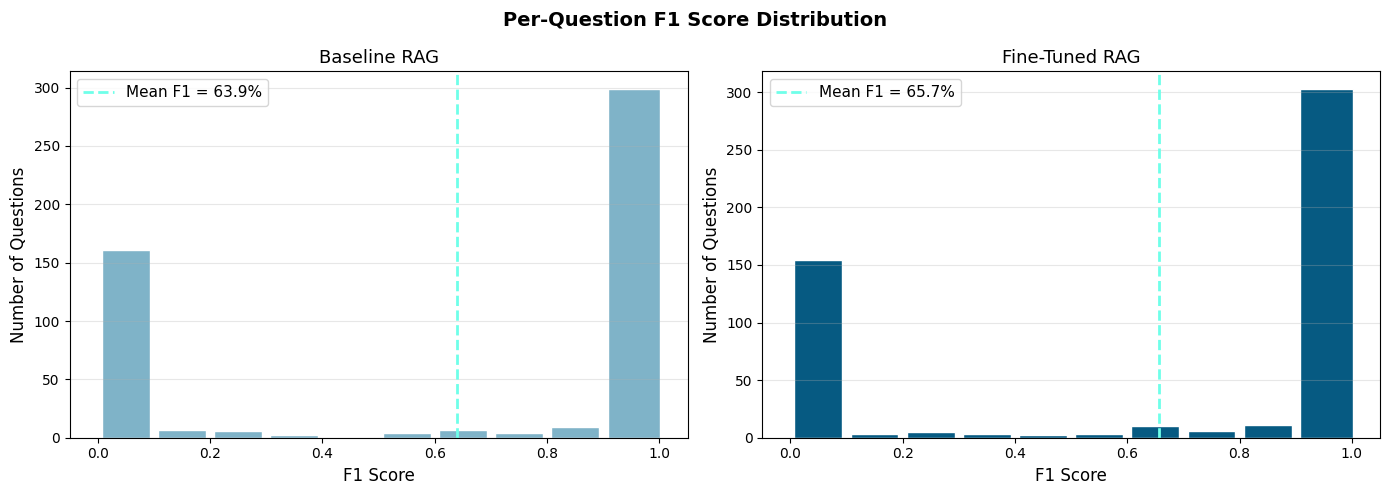

Saved → results/viz6_f1_distribution.png


In [17]:
# ── Visualization 6: F1 Score Distribution & Error Analysis ──────────────────
from evaluate import load as load_metric

def token_f1(pred: str, gold: str) -> float:
    """Token-level F1 between prediction and gold answer."""
    pred_toks = pred.lower().split()
    gold_toks = gold.lower().split()
    if not pred_toks or not gold_toks:
        return float(pred == gold)
    common = len(set(pred_toks) & set(gold_toks))
    if common == 0:
        return 0.0
    p = common / len(pred_toks)
    r = common / len(gold_toks)
    return 2 * p * r / (p + r)

# Compute per-question F1 for both models
baseline_f1s = []
ft_f1s       = []

for pred_b, pred_f, ref in zip(baseline_preds, ft_preds, baseline_refs):
    golds = ref["answers"]["text"]
    if not golds:
        # Unanswerable: correct if prediction is empty
        baseline_f1s.append(1.0 if pred_b["prediction_text"] == "" else 0.0)
        ft_f1s.append(1.0 if pred_f["prediction_text"] == "" else 0.0)
    else:
        baseline_f1s.append(max(token_f1(pred_b["prediction_text"], g) for g in golds))
        ft_f1s.append(max(token_f1(pred_f["prediction_text"], g) for g in golds))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Per-Question F1 Score Distribution", fontsize=14, fontweight="bold")

for ax, f1s, label, color in zip(
    axes,
    [baseline_f1s, ft_f1s],
    ["Baseline RAG", "Fine-Tuned RAG"],
    ["#7FB3C8", "#065A82"]
):
    bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
    ax.hist(f1s, bins=bins, color=color, edgecolor="white", rwidth=0.85)
    ax.axvline(np.mean(f1s), color="#6FFFE9", linestyle="--", linewidth=2,
               label=f"Mean F1 = {np.mean(f1s)*100:.1f}%")
    ax.set_xlabel("F1 Score", fontsize=12)
    ax.set_ylabel("Number of Questions", fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=11)
    ax.set_xlim(-0.05, 1.05)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/viz6_f1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/viz6_f1_distribution.png")

In [18]:
# ── Qualitative Error Analysis Table ─────────────────────────────────────────
# Find the most interesting cases: baseline fails, fine-tuned succeeds

improvements = []
for i, (bp, fp, ref, ex) in enumerate(zip(baseline_preds, ft_preds, baseline_refs, val_sample)):
    golds = ref["answers"]["text"]
    if not golds:
        continue
    b_f1 = max(token_f1(bp["prediction_text"], g) for g in golds)
    f_f1 = max(token_f1(fp["prediction_text"], g) for g in golds)
    if f_f1 > b_f1 + 0.3:   # big improvement
        improvements.append({
            "question": ex["question"],
            "gold": golds[0],
            "baseline_pred": bp["prediction_text"] or "[no answer]",
            "ft_pred": fp["prediction_text"] or "[no answer]",
            "baseline_f1": round(b_f1, 3),
            "ft_f1": round(f_f1, 3),
        })

print(f"Found {len(improvements)} cases where fine-tuning improved F1 by >30 points.\n")
print(f"{'='*80}")
print(f"QUALITATIVE ERROR ANALYSIS — Baseline Fails, Fine-Tuned Succeeds")
print(f"{'='*80}")

for case in improvements[:5]:
    print(f"\nQuestion  : {case['question']}")
    print(f"Gold      : {case['gold']}")
    print(f"Baseline  : {case['baseline_pred']}  (F1={case['baseline_f1']:.2f})")
    print(f"Fine-Tuned: {case['ft_pred']}  (F1={case['ft_f1']:.2f})")
    print(f"{'-'*80}")

# Save
with open("results/error_analysis.json", "w") as f:
    json.dump(improvements[:20], f, indent=2)
print("\nSaved → results/error_analysis.json")

Found 18 cases where fine-tuning improved F1 by >30 points.

QUALITATIVE ERROR ANALYSIS — Baseline Fails, Fine-Tuned Succeeds

Question  : What river was Petrela located by?
Gold      : Deabolis
Baseline  : River Aare  (F1=0.40)
Fine-Tuned: Deabolis  (F1=1.00)
--------------------------------------------------------------------------------

Question  : Who did Emma Marry?
Gold      : King Ethelred II
Baseline  : [no answer]  (F1=0.00)
Fine-Tuned: Duke Richard II of Normandy, and King Ethelred II of England  (F1=0.43)
--------------------------------------------------------------------------------

Question  : Who was Emma's brother?
Gold      : Duke Richard II
Baseline  : [no answer]  (F1=0.00)
Fine-Tuned: Duke Richard II of Normandy  (F1=0.75)
--------------------------------------------------------------------------------

Question  : By what main attribute are computational problems classified utilizing computational complexity theory? 
Gold      : inherent difficulty
Baseline  : an

---
## 7 · Final Results Summary

In [19]:
# ── Final Results Table ───────────────────────────────────────────────────────
HUMAN_EM = 86.9
HUMAN_F1 = 89.5

results_table = pd.DataFrame([
    {
        "Model": "Human Performance (SQuAD 2.0 paper)",
        "Exact Match (%)": HUMAN_EM,
        "F1 (%)": HUMAN_F1,
        "Notes": "Upper bound"
    },
    {
        "Model": "Baseline RAG (Frozen deepset/deberta-v3-base-squad2)",
        "Exact Match (%)": round(baseline_scores["exact"], 2),
        "F1 (%)": round(baseline_scores["f1"], 2),
        "Notes": "No fine-tuning"
    },
    {
        "Model": "Fine-Tuned RAG (QLoRA on deberta-v3-base)",
        "Exact Match (%)": round(ft_scores["exact"], 2),
        "F1 (%)": round(ft_scores["f1"], 2),
        "Notes": f"LoRA r=16, α=32, {TRAIN_SUBSET:,} train examples"
    },
])

print("\n" + "="*80)
print(" FINAL RESULTS SUMMARY")
print("="*80)
print(results_table.to_string(index=False))
print("="*80)

em_gain = ft_scores["exact"] - baseline_scores["exact"]
f1_gain = ft_scores["f1"]    - baseline_scores["f1"]
print(f"\n  EM improvement from fine-tuning : +{em_gain:.2f}%")
print(f"  F1 improvement from fine-tuning : +{f1_gain:.2f}%")

results_table.to_csv("results/final_results.csv", index=False)
print("\nSaved → results/final_results.csv")

print("\n📁 All results saved to results/:")
for f in sorted(os.listdir("results")):
    size = os.path.getsize(f"results/{f}") / 1024
    print(f"   {f:<45} {size:.1f} KB")


 FINAL RESULTS SUMMARY
                                               Model  Exact Match (%)  F1 (%)                                   Notes
                 Human Performance (SQuAD 2.0 paper)             86.9   89.50                             Upper bound
Baseline RAG (Frozen deepset/deberta-v3-base-squad2)             61.4   64.49                          No fine-tuning
           Fine-Tuned RAG (QLoRA on deberta-v3-base)             62.8   66.37 LoRA r=16, α=32, 130,319 train examples

  EM improvement from fine-tuning : +1.40%
  F1 improvement from fine-tuning : +1.88%

Saved → results/final_results.csv

📁 All results saved to results/:
   baseline_scores.json                          0.4 KB
   error_analysis.json                           5.8 KB
   final_results.csv                             0.3 KB
   finetuned_scores.json                         0.4 KB
   training_log.json                             10.9 KB
   viz1_dataset_exploration.png                  85.6 KB
   viz2_tr

---
## 8 · Tips to Push F1 Even Higher

If you want to climb the leaderboard further, here are the highest-leverage changes:

| Technique | Expected F1 gain | Effort | Notes |
|-----------|-----------------|--------|-------|
| Train on **full** dataset (130K examples) | +3–5% | Medium | Change `TRAIN_SUBSET = len(train_data)` |
| Increase **LoRA rank** to r=32 | +1–2% | Low | More params, slightly more VRAM |
| Add a **cross-encoder re-ranker** | +2–4% | Medium | `cross-encoder/ms-marco-MiniLM-L-6-v2` |
| Use `deberta-v3-large` instead of base | +3–5% | Medium | Needs A100 for QLoRA |
| Tune **no-answer threshold** | +1–3% | Low | Grid search over `no_answer_threshold` |
| **Ensemble** base + large predictions | +1–2% | High | Vote across models |

---

## Dependencies Summary

```
transformers==4.40.0
datasets==2.19.0
peft==0.10.0
bitsandbytes==0.43.1
accelerate==0.29.3
sentence-transformers==2.7.0
faiss-gpu==1.7.2
evaluate==0.4.1
umap-learn
matplotlib seaborn pandas tqdm
```

**Hardware**: Google Colab Pro — A100 (40 GB) recommended. T4 (16 GB) works but training will take ~2× longer.

**Reproducibility**: All random seeds fixed to 42. Results may vary slightly due to GPU non-determinism.

**Data**: SQuAD 2.0 — CC BY-SA 4.0 license. No full dataset uploaded; loaded via HuggingFace `datasets` at runtime.

---
*Foundations of Large Language Models*